# Create a figure to show the enhanced noise protection of CCD
- show using square noise distribution the infidelity you get from rabi and from ccd in central region for identity
- do it by making a plot of fidelity with detuning 
- then sum over an increasing window with width $\delta \omega$

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [23]:
steel_blue, plum = "#4682B4", "#B44682"

In [24]:

import os
import sys


# --- PATH modification for TinyTeX (BEGIN) ---
tinytex_bin_path = os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin")
if os.path.exists(tinytex_bin_path):
    if tinytex_bin_path not in os.environ['PATH']:
        os.environ['PATH'] = tinytex_bin_path + os.pathsep + os.environ['PATH']
        print(f"Added {tinytex_bin_path} to PATH for this Python session.")
    else:
        print(f"{tinytex_bin_path} already in PATH for this session.")
else:
    print(f"Warning: TinyTeX bin path not found at {tinytex_bin_path}. LaTeX rendering might fail.")
# --- PATH modification for TinyTeX (END) ---


# --- Matplotlib Configuration for LaTeX Integration ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 12,
    "axes.titlesize": 10,
})



# --- Figure Dimensions for Your LaTeX Document ---
pt_to_inches = 1.0 / 72.27
latex_textwidth_pts = 469.75502 # Standard for A4 article, 10pt
latex_fig_width_inches =1 * latex_textwidth_pts * pt_to_inches  

# Calculate column width: (textwidth - columnsep) / 2
# Your LaTeX sets \columnsep to 0.75cm. Convert 0.75cm to points.
# column_sep_cm = 0.75
# column_sep_pts = column_sep_cm * (72.27 / 2.54) # 72.27 pts/inch, 2.54 cm/inch

# latex_column_width_pts = (latex_textwidth_pts - column_sep_pts) / 2

# # Set figure width to match the calculated column width
# latex_fig_width_inches = latex_column_width_pts * pt_to_inches


# latex_fig_height_inches = latex_fig_width_inches


/Users/archie/Library/TinyTeX/bin/universal-darwin already in PATH for this session.


# CCD

In [25]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
tol = 10**-12
evaluation_points = 2001
evaluation_time = 8/rabi_freq 

# iteration parameters
detunings = np.linspace(-2*rabi_freq, 2*rabi_freq, 1000)

fids_ccd = []



for detuning in detunings:
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol, rtol=tol)
    fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    

    fids_ccd.append(fid_1)




In [26]:
closest_time = times[np.argmin(np.abs(times - ( 4/ rabi_freq)))]
print(closest_time)

800.0


In [27]:
time_index = np.argmin(np.abs(times - ( 4/ rabi_freq)))
final_fids_ccd = [fid[time_index] for fid in fids_ccd]
detunings_normalized = detunings / rabi_freq

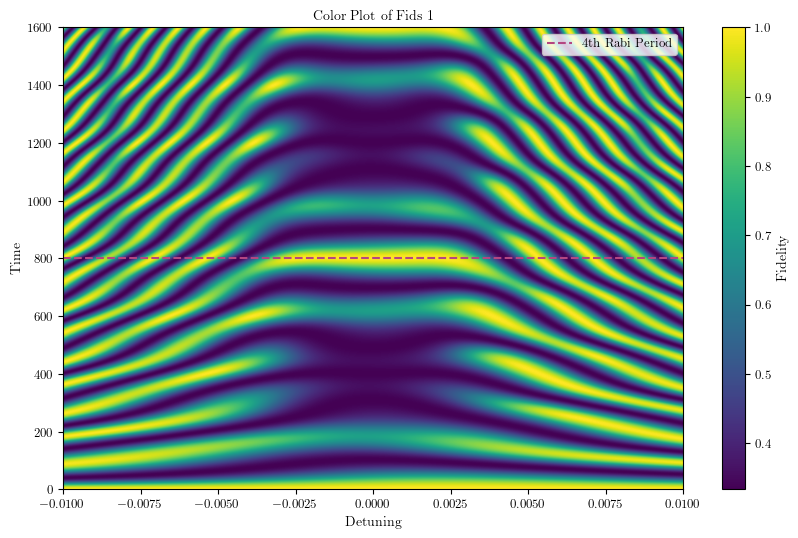

In [28]:
plt.figure(figsize=(10, 6))
plt.imshow(np.array(fids_ccd).T, aspect='auto', extent=[detunings[0], detunings[-1], 0, evaluation_time], origin='lower', cmap='viridis')
plt.colorbar(label='Fidelity')
plt.axhline(y=4/rabi_freq, color=plum, linestyle='--', label='4th Rabi Period')  # Add plum line
plt.xlabel('Detuning')
plt.ylabel('Time')
plt.title('Color Plot of Fids 1')
plt.legend()
plt.show()

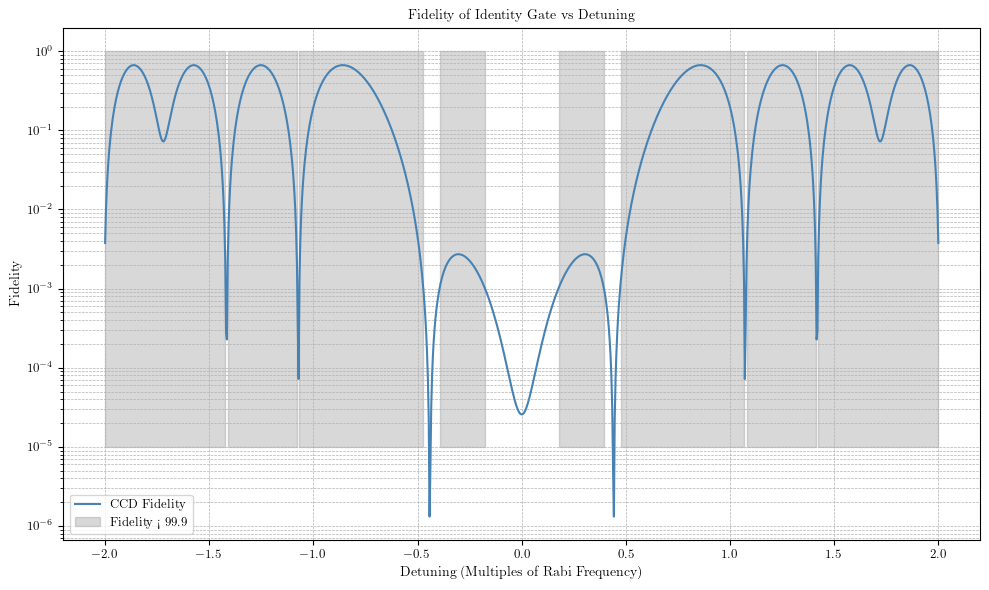

In [29]:
# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, 1-np.array(final_fids_ccd), label="CCD Fidelity", color=steel_blue)

# Highlight regions where fidelity drops below 99.9%
threshold = 0.999
below_threshold = np.array(final_fids_ccd) < threshold
plt.fill_between(detunings_normalized, 10**-5, 1, where=below_threshold, color='grey', alpha=0.3, label="Fidelity < 99.9%")

plt.xlabel("Detuning (Multiples of Rabi Frequency)")
plt.ylabel("Fidelity")
plt.title("Fidelity of Identity Gate vs Detuning")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


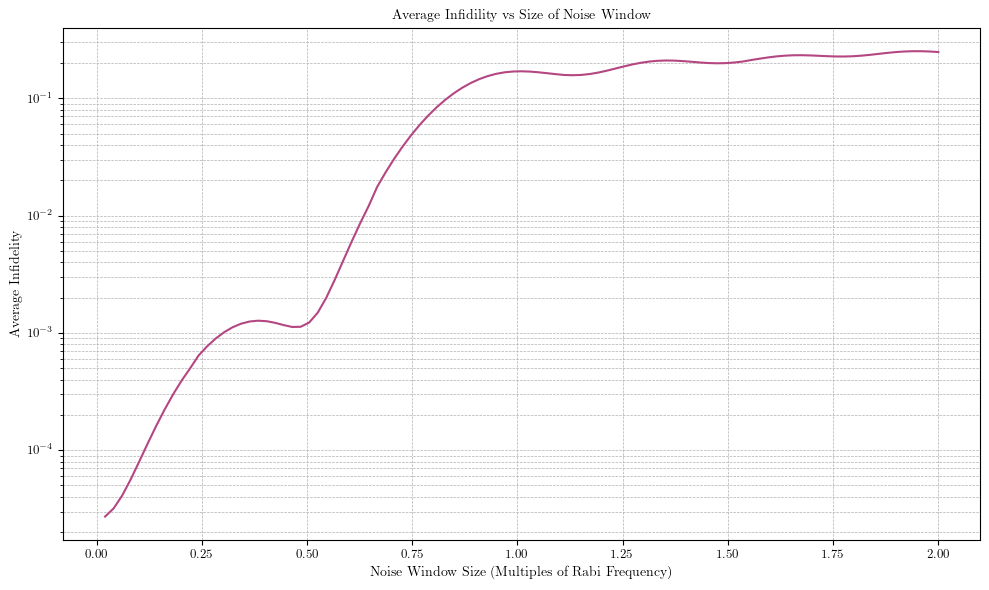

In [30]:
# Define the range of delta values
delta_values = np.linspace(0, max(detunings_normalized), 100)

# Calculate the average fidelity for each delta
average_infidelities_ccd = []
for delta in delta_values:
    indices = np.where((detunings_normalized >= -delta) & (detunings_normalized <= delta))
    avg_fid = np.mean([(1-final_fids_ccd[i]) for i in indices[0]])
    average_infidelities_ccd.append(avg_fid)

# Plot the average fidelity against delta
plt.figure(figsize=(10, 6))
plt.semilogy(delta_values, average_infidelities_ccd, color=plum, label="Average Infidelity")
plt.xlabel("Noise Window Size (Multiples of Rabi Frequency)")
plt.ylabel("Average Infidelity")
plt.title("Average Infidility vs Size of Noise Window")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.legend()
plt.tight_layout()
plt.show()

# Rabi

In [31]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005




# Integration parameters
tol = 10**-12
evaluation_points = 2001
evaluation_time = 8/rabi_freq

# iteration parameters
detunings = np.linspace(-2*rabi_freq, 2*rabi_freq, 1000)

fids_rabi = []




for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(
        1, 
        evaluation_time, 
        evaluation_points, 
        hamiltonians.rabi_rwa, 
        natural_freq=natural_freq-detuning, 
        driving_freq=driving_freq, 
        rabi_freq=rabi_freq, 
        atol=tol, 
        rtol=tol
    )
    fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_rabi.append(fid_1)




In [32]:
time_index = np.argmin(np.abs(times - ( 4/ rabi_freq)))
final_fids_rabi = [fid[time_index] for fid in fids_rabi]
detunings_normalized = detunings / rabi_freq

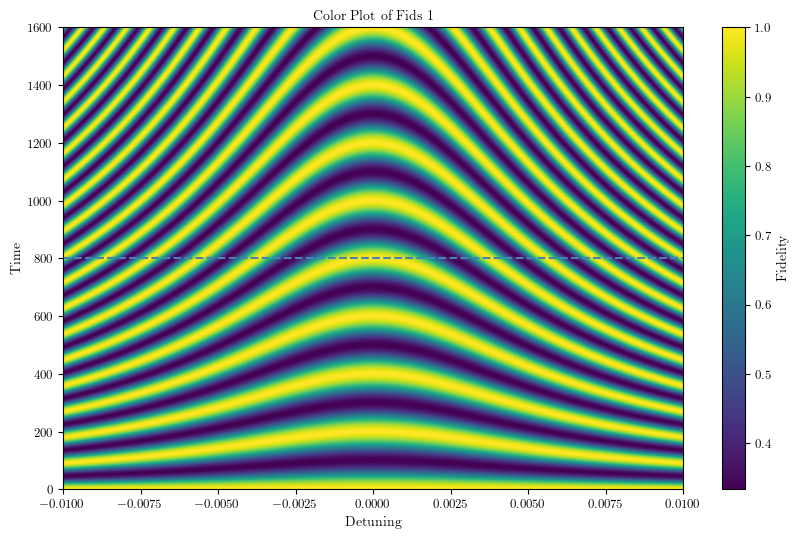

In [33]:
plt.figure(figsize=(10, 6))
plt.imshow(np.array(fids_rabi).T, aspect='auto', extent=[detunings[0], detunings[-1], 0, evaluation_time], origin='lower', cmap='viridis')
plt.axhline(y=4/rabi_freq, color=steel_blue, linestyle='--', label='4th Rabi Period')  # Add plum line
plt.colorbar(label='Fidelity')
plt.xlabel('Detuning')
plt.ylabel('Time')
plt.title('Color Plot of Fids 1')
plt.show()

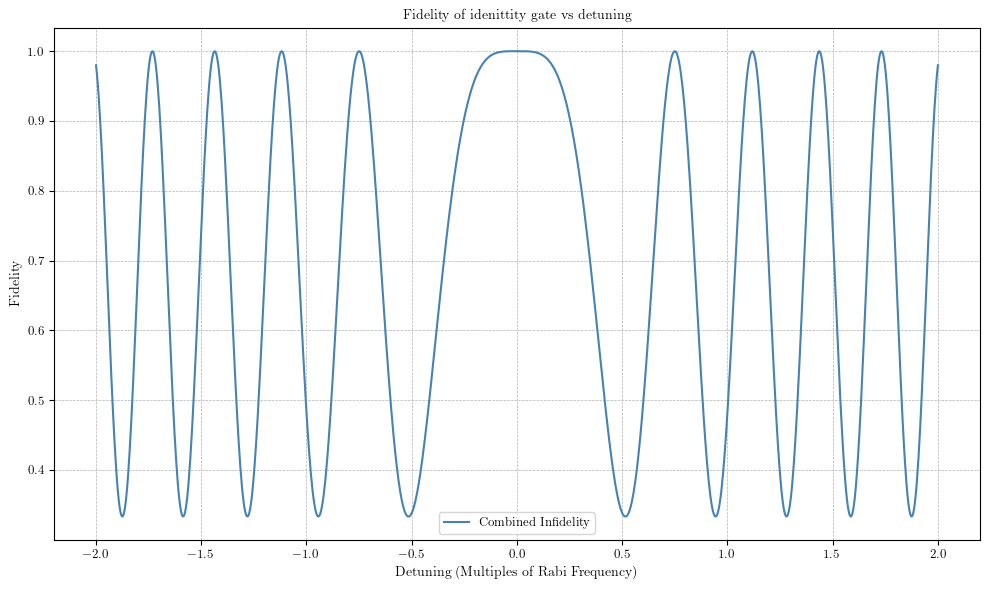

In [34]:


# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.plot(detunings_normalized, final_fids_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning (Multiples of Rabi Frequency)")
plt.ylabel("Fidelity")
plt.title("Fidelity of idenittity gate vs detuning")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


- I am going to choose to do it after 4 rabi oscillations for both - as that makes it fairer??

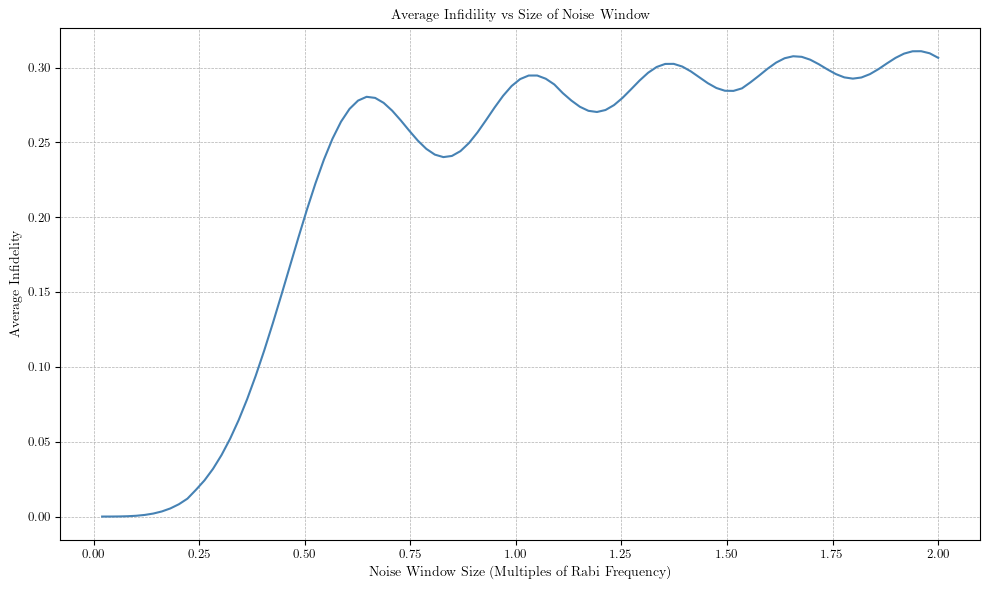

In [35]:
# Define the range of delta values
delta_values = np.linspace(0, max(detunings_normalized), 100)

# Calculate the average fidelity for each delta
average_infidelities_rabi = []
for delta in delta_values:
    indices = np.where((detunings_normalized >= -delta) & (detunings_normalized <= delta))
    avg_fid = np.mean([(1-final_fids_rabi[i]) for i in indices[0]])
    average_infidelities_rabi.append(avg_fid)

# Plot the average fidelity against delta
plt.figure(figsize=(10, 6))
plt.plot(delta_values, average_infidelities_rabi, color=steel_blue, label="Average Infidelity")
plt.xlabel("Noise Window Size (Multiples of Rabi Frequency)")
plt.ylabel("Average Infidelity")
plt.title("Average Infidility vs Size of Noise Window")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# plt.legend()
plt.tight_layout()
plt.show()

# Combined - non logged - 

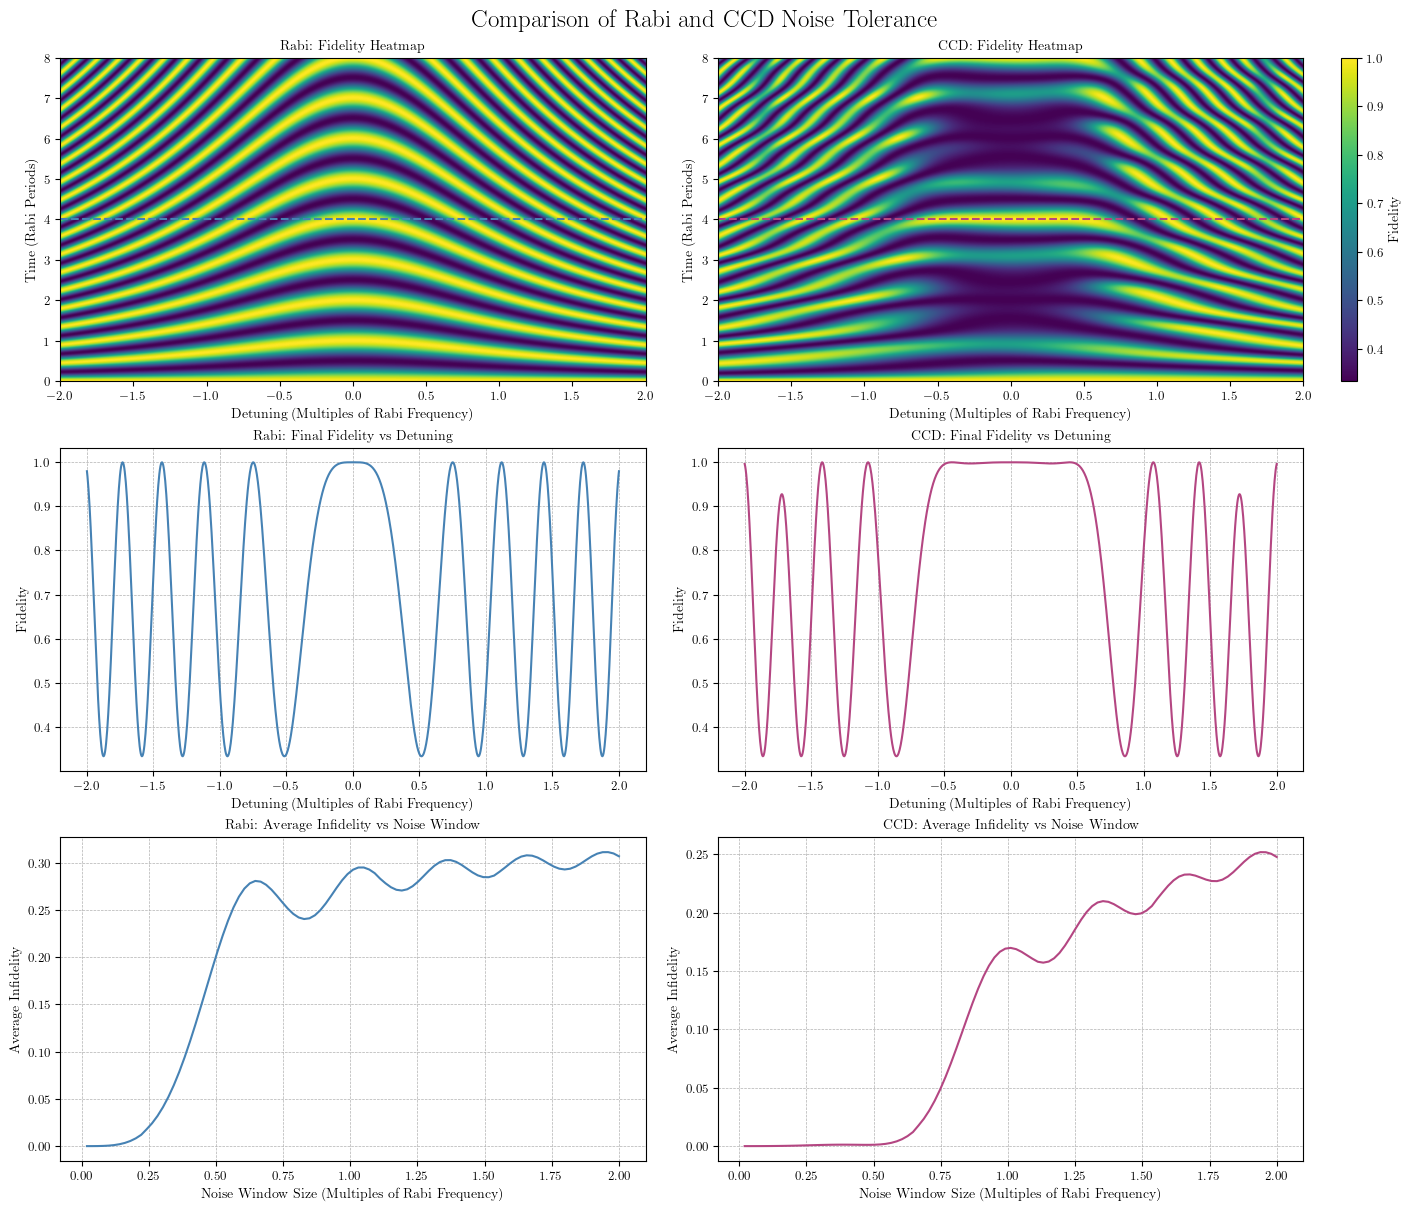

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

# Top row: Heatmaps
im1 = axes[0, 0].imshow(np.array(fids_rabi).T, aspect='auto', extent=[detunings_normalized[0], detunings_normalized[-1], 0, evaluation_time * rabi_freq], origin='lower', cmap='viridis', vmin=1/3, vmax=1)
# add horizontal line at 4/rabi_freq
axes[0, 0].axhline(y=4, color=steel_blue, linestyle='--', label='4th Rabi Period')
axes[0, 0].set_title("Rabi: Fidelity Heatmap")
axes[0, 0].set_xlabel("Detuning (Multiples of Rabi Frequency)")
axes[0, 0].set_ylabel("Time (Rabi Periods)")

im2 = axes[0, 1].imshow(np.array(fids_ccd).T, aspect='auto', extent=[detunings_normalized[0], detunings_normalized[-1], 0, evaluation_time * rabi_freq], origin='lower', cmap='viridis', vmin=1/3, vmax=1)
# add horisontal line at 4/rabi_freq
axes[0, 1].axhline(y=4, color=plum, linestyle='--', label='4th Rabi Period')
axes[0, 1].set_title("CCD: Fidelity Heatmap")
axes[0, 1].set_xlabel("Detuning (Multiples of Rabi Frequency)")
axes[0, 1].set_ylabel("Time (Rabi Periods)")

fig.colorbar(im2, ax=axes[0, 1], label="Fidelity")

# Middle row: Final fidelities
axes[1, 0].plot(detunings_normalized, final_fids_rabi, label="Final Fidelity", color=steel_blue)
axes[1, 0].set_title("Rabi: Final Fidelity vs Detuning")
axes[1, 0].set_xlabel("Detuning (Multiples of Rabi Frequency)")
axes[1, 0].set_ylabel("Fidelity")
axes[1, 0].grid(True, which="both", linestyle="--", linewidth=0.5)

axes[1, 1].plot(detunings_normalized, final_fids_ccd, label="Final Fidelity", color=plum)
axes[1, 1].set_title("CCD: Final Fidelity vs Detuning")
axes[1, 1].set_xlabel("Detuning (Multiples of Rabi Frequency)")
axes[1, 1].set_ylabel("Fidelity")
axes[1, 1].grid(True, which="both", linestyle="--", linewidth=0.5)

# Bottom row: Averaged infidelities
axes[2, 0].plot(delta_values, average_infidelities_rabi, color=steel_blue, label="Average Infidelity")
axes[2, 0].set_title("Rabi: Average Infidelity vs Noise Window")
axes[2, 0].set_xlabel("Noise Window Size (Multiples of Rabi Frequency)")
axes[2, 0].set_ylabel("Average Infidelity")
axes[2, 0].grid(True, which="both", linestyle="--", linewidth=0.5)

axes[2, 1].plot(delta_values, average_infidelities_ccd, color=plum, label="Average Infidelity")
axes[2, 1].set_title("CCD: Average Infidelity vs Noise Window")
axes[2, 1].set_xlabel("Noise Window Size (Multiples of Rabi Frequency)")
axes[2, 1].set_ylabel("Average Infidelity")
axes[2, 1].grid(True, which="both", linestyle="--", linewidth=0.5)

# Add annotations for Rabi and CCD
# axes[0, 0].annotate("Rabi Scheme", xy=(0.5, 1.15), xycoords="axes fraction", ha="center", fontsize=18)
# axes[0, 1].annotate("CCD Scheme", xy=(0.5, 1.15), xycoords="axes fraction", ha="center", fontsize=18)

plt.suptitle("Comparison of Rabi and CCD Noise Tolerance", fontsize=18)

plt.show()

# Combined - logged and greyed

In [37]:
# Find the index where detuning is closest to 0
zero_detuning_index = np.argmin(np.abs(detunings))
rabi_fidelity_at_zero_detuning = final_fids_rabi[zero_detuning_index]

#print the closest detuning
closest_detuning = detunings[zero_detuning_index]
print("Closest Detuning to 0:", closest_detuning)

# Print the Rabi fidelity at 0 detuning
print("Rabi Fidelity at 0 Detuning:", rabi_fidelity_at_zero_detuning)

Closest Detuning to 0: -1.0010010010009715e-05
Rabi Fidelity at 0 Detuning: 0.9999999995704122


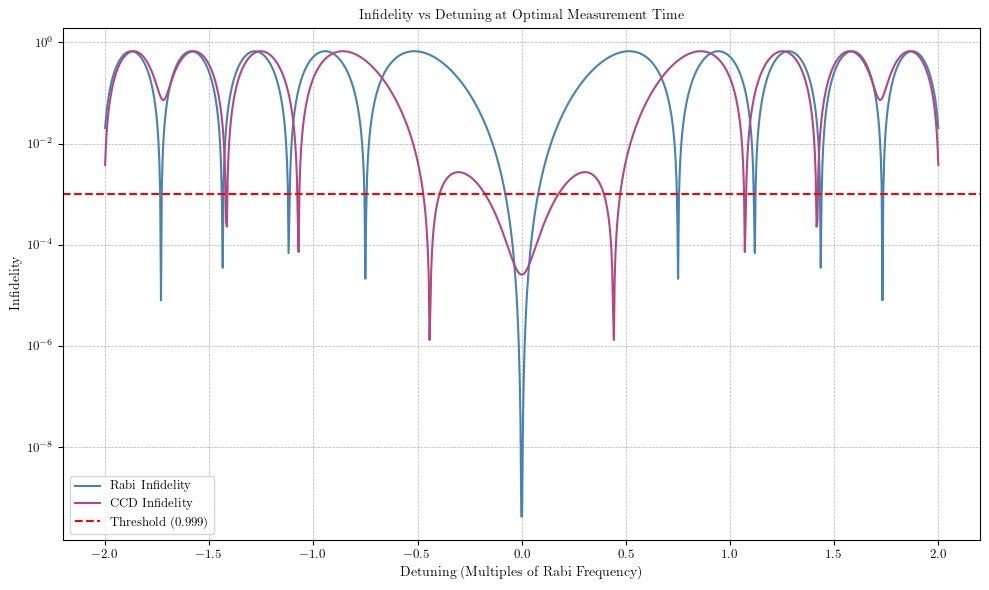

In [38]:
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, 1 - np.array(final_fids_rabi), label="Rabi Infidelity", color=steel_blue)
plt.semilogy(detunings_normalized, 1 - np.array(final_fids_ccd), label="CCD Infidelity", color=plum)

plt.axhline(y=1e-3, color='red', linestyle='--', label="Threshold (0.999)")

plt.xlabel("Detuning (Multiples of Rabi Frequency)")
plt.ylabel("Infidelity")
plt.title("Infidelity vs Detuning at Optimal Measurement Time")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.titlesize": 14,
    "axes.titlesize": 14,
})



6.5000002767400025


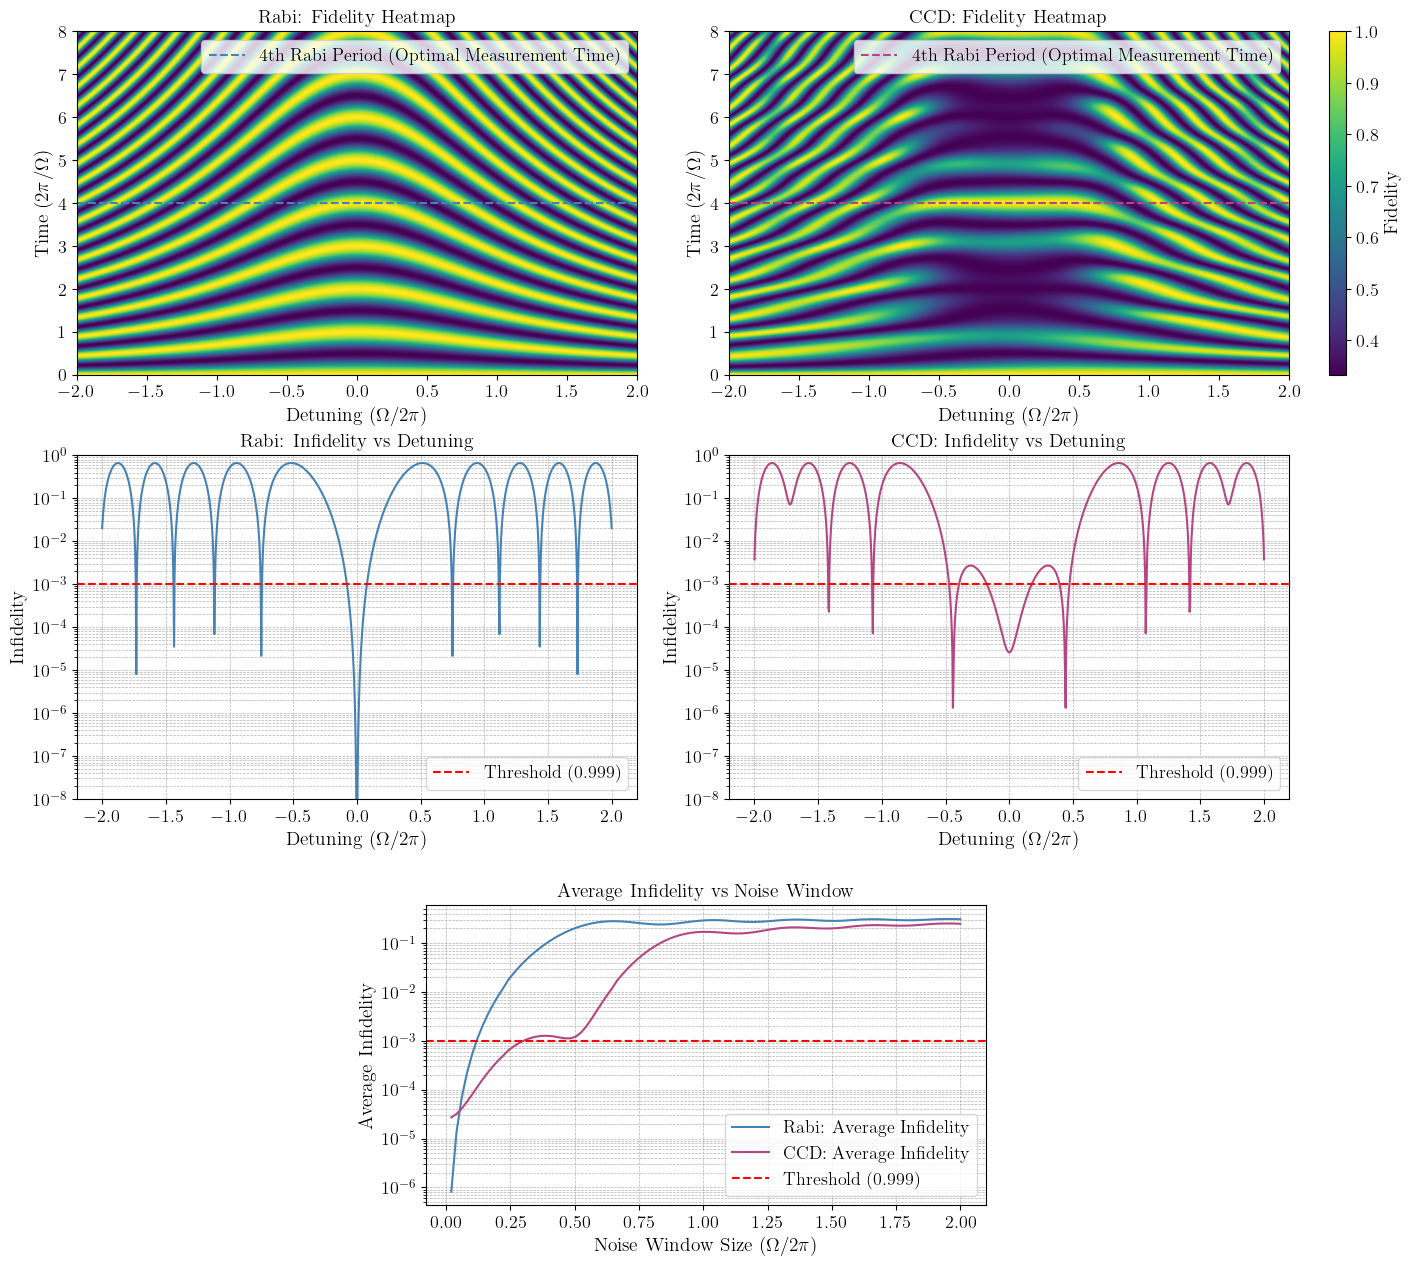

In [81]:
import matplotlib.pyplot as plt
import numpy as np # Assuming you have this import

# Assume the following variables are defined elsewhere in your script:
# latex_fig_width_inches, fids_rabi, fids_ccd, detunings_normalized,
# evaluation_time, rabi_freq, steel_blue, plum, final_fids_rabi, final_fids_ccd,
# delta_values, average_infidelities_rabi, average_infidelities_ccd

fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
print(latex_fig_width_inches)


# Top row: Heatmaps
im1 = axes[0, 0].imshow(np.array(fids_rabi).T, aspect='auto', extent=[detunings_normalized[0], detunings_normalized[-1], 0, evaluation_time * rabi_freq], origin='lower', cmap='viridis', vmin=1/3, vmax=1)
# add horizontal line at 4/rabi_freq
axes[0, 0].axhline(y=4, color=steel_blue, linestyle='--', label='4th Rabi Period (Optimal Measurement Time)')
axes[0, 0].set_title("Rabi: Fidelity Heatmap")
axes[0, 0].set_xlabel(r"Detuning ($\Omega/2\pi$)") # Changed
axes[0, 0].set_ylabel(r"Time ($2\pi/\Omega$)")       # Changed
axes[0, 0].legend(loc='upper right')

im2 = axes[0, 1].imshow(np.array(fids_ccd).T, aspect='auto', extent=[detunings_normalized[0], detunings_normalized[-1], 0, evaluation_time * rabi_freq], origin='lower', cmap='viridis', vmin=1/3, vmax=1)
axes[0, 1].axhline(y=4, color=plum, linestyle='--', label='4th Rabi Period (Optimal Measurement Time)')
axes[0, 1].set_title("CCD: Fidelity Heatmap")
axes[0, 1].set_xlabel(r"Detuning ($\Omega/2\pi$)") # Changed
axes[0, 1].set_ylabel(r"Time ($2\pi/\Omega$)")        # Changed
axes[0, 1].legend(loc='upper right')

fig.colorbar(im2, ax=axes[0, 1], label="Fidelity")

# Middle row: Final fidelities
axes[1, 0].semilogy(detunings_normalized, 1 - np.array(final_fids_rabi), color=steel_blue)
axes[1, 0].axhline(y=1e-3, color='red', linestyle='--', label="Threshold (0.999)")
axes[1, 0].set_title("Rabi: Infidelity vs Detuning")
axes[1, 0].set_xlabel(r"Detuning ($\Omega/2\pi$)") # Changed
axes[1, 0].set_ylabel("Infidelity")
axes[1, 0].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[1, 0].legend(loc='lower right')

axes[1, 1].semilogy(detunings_normalized, 1 - np.array(final_fids_ccd), color=plum)
axes[1, 1].axhline(y=1e-3, color='red', linestyle='--', label="Threshold (0.999)")
axes[1, 1].set_title("CCD: Infidelity vs Detuning")
axes[1, 1].set_xlabel(r"Detuning ($\Omega/2\pi$)") # Changed
axes[1, 1].set_ylabel("Infidelity")
axes[1, 1].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[1, 1].legend(loc='lower right')

# set the y-axis limits for both middle plots to the same range
axes[1, 0].set_ylim(1e-8, 1)
axes[1, 1].set_ylim(1e-8, 1)

# Bottom row: Averaged infidelities
axes[2, 0].semilogy(delta_values, average_infidelities_rabi, color=steel_blue, label="Rabi: Average Infidelity")
axes[2, 0].semilogy(delta_values, average_infidelities_ccd, color=plum, label="CCD: Average Infidelity")
axes[2, 0].axhline(y=1e-3, color='red', linestyle='--', label="Threshold (0.999)")
axes[2, 0].set_title("Average Infidelity vs Noise Window")
axes[2, 0].set_xlabel(r"Noise Window Size ($\Omega/2\pi$)") # Changed
axes[2, 0].set_ylabel("Average Infidelity")
axes[2, 0].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[2, 0].legend()

# Center the plot in the combined figure
axes[2, 0].set_position([0.3, 0.0, 0.4, 0.25])  # Adjust position: [left, bottom, width, height]/

# set the final plot visibility to false
axes[2, 1].set_visible(False)  # Hide the last subplot


# Add annotations for Rabi and CCD
# axes[0, 0].annotate("Rabi Scheme", xy=(0.5, 1.15), xycoords="axes fraction", ha="center", fontsize=18)
# axes[0, 1].annotate("CCD Scheme", xy=(0.5, 1.15), xycoords="axes fraction", ha="center", fontsize=18)

# plt.suptitle("Comparison of Rabi and CCD Noise Tolerance", fontsize=18)
plt.savefig('/Users/archie/documents/year4/project/Figures_Final/ccd_vs_rabi_noise_tolerance_identity.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [60]:
# Find indices where fidelity is greater than or equal to 0.999 for Rabi and CCD
rabi_indices = np.where(np.array(average_infidelities_rabi) >= 0.001)[0]
ccd_indices = np.where(np.array(average_infidelities_ccd) >= 0.001)[0]


print(delta_values[rabi_indices[0]])
print(delta_values[ccd_indices[0]])

0.12121212121212122
0.30303030303030304


In [40]:
#